In [ ]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

df = pd.read_excel("/content/dorm_electricity_usage (2).xlsx")


df["Datetime"] = pd.to_datetime(df["Datetime"])

df["Moving_Average_3hr"] = df["Electricity_kWh"].rolling(window=3).mean()

df["Hour_Index"] = np.arange(len(df))

evening_df = df[df["Datetime"].dt.hour.between(18, 22)]

X = evening_df[["Hour_Index"]]
y = evening_df["Electricity_kWh"]

model = LinearRegression()
model.fit(X, y)

df["Predicted_Peak_kWh"] = model.predict(df[["Hour_Index"]])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["Datetime"],
    y=df["Electricity_kWh"],
    mode="lines",
    name="Actual Electricity Usage"
))

fig.add_trace(go.Scatter(
    x=df["Datetime"],
    y=df["Moving_Average_3hr"],
    mode="lines",
    name="3-Hour Moving Average"
))

fig.add_trace(go.Scatter(
    x=df["Datetime"],
    y=df["Predicted_Peak_kWh"],
    mode="lines",
    name="Predicted Evening Peak"
))

fig.update_layout(
    title="Dormitory Electricity Usage – Peak Hour Analysis",
    xaxis_title="Time",
    yaxis_title="Electricity Consumption (kWh)",
    template="plotly_white"
)

fig.show()


ACTUAL vs PREDICTED EVENING PEAK TABLE

           date  actual_peak_hour  predicted_peak_hour
22   2026-01-01                22                   22
46   2026-01-02                22                   22
68   2026-01-03                20                   22
94   2026-01-04                22                   22
118  2026-01-05                22                   22
142  2026-01-06                22                   22
166  2026-01-07                22                   22


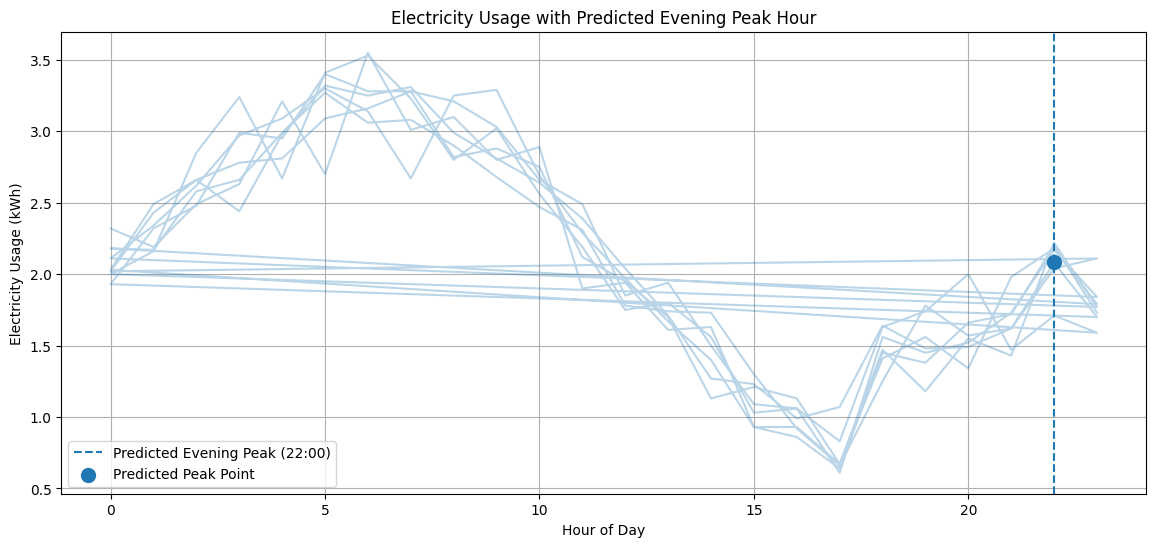

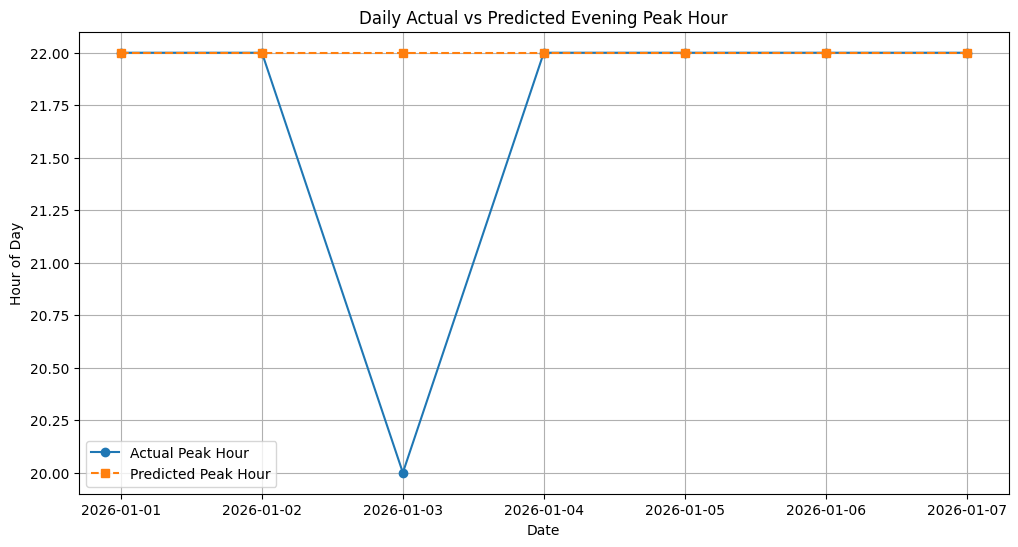


Predicted Evening Peak Hour (Overall): 22:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/dorm_electricity_usage (2).xlsx")
df['Datetime'] = pd.to_datetime(df['Datetime'])

df['date'] = df['Datetime'].dt.date
df['hour'] = df['Datetime'].dt.hour

hourly_df = df.groupby(['date', 'hour'], as_index=False)['Electricity_kWh'].mean()
hourly_df.rename(columns={'Electricity_kWh': 'usage'}, inplace=True)

evening_df = hourly_df[(hourly_df['hour'] >= 18) & (hourly_df['hour'] <= 22)]

actual_peaks = evening_df.loc[
    evening_df.groupby('date')['usage'].idxmax()
][['date', 'hour', 'usage']]

actual_peaks.rename(columns={
    'hour': 'actual_peak_hour',
    'usage': 'actual_peak_usage'
}, inplace=True)

hourly_avg = evening_df.groupby('hour')['usage'].mean()

predicted_evening_hour = hourly_avg.idxmax()
predicted_evening_usage = hourly_avg.max()

actual_peaks['predicted_peak_hour'] = predicted_evening_hour

print("\nACTUAL vs PREDICTED EVENING PEAK TABLE\n")
print(actual_peaks[['date', 'actual_peak_hour', 'predicted_peak_hour']])

plt.figure(figsize=(14,6))

plt.plot(hourly_df['hour'], hourly_df['usage'], alpha=0.3)

plt.axvline(
    x=predicted_evening_hour,
    linestyle='--',
    label=f'Predicted Evening Peak ({predicted_evening_hour}:00)'
)

plt.scatter(
    predicted_evening_hour,
    predicted_evening_usage,
    s=100,
    label='Predicted Peak Point'
)

plt.xlabel("Hour of Day")
plt.ylabel("Electricity Usage (kWh)")
plt.title("Electricity Usage with Predicted Evening Peak Hour")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))

plt.plot(actual_peaks['date'], actual_peaks['actual_peak_hour'],
         marker='o', label='Actual Peak Hour')

plt.plot(actual_peaks['date'], actual_peaks['predicted_peak_hour'],
         marker='s', linestyle='--', label='Predicted Peak Hour')

plt.xlabel("Date")
plt.ylabel("Hour of Day")
plt.title("Daily Actual vs Predicted Evening Peak Hour")
plt.legend()
plt.grid(True)
plt.show()
print(f"\nPredicted Evening Peak Hour (Overall): {predicted_evening_hour}:00")